### Лабораторная работа №2 по ТМО

#### Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных.

Цель лабораторной работы: изучение способов предварительной обработки данных для дальнейшего формирования моделей.

Задание:

    Выбрать набор данных (датасет), содержащий категориальные признаки и пропуски в данных. Для выполнения следующих пунктов можно использовать несколько различных наборов данных (один для обработки пропусков, другой для категориальных признаков и т.д.)
    Для выбранного датасета (датасетов) на основе материалов лекции решить следующие задачи:
        обработку пропусков в данных;
        кодирование категориальных признаков;
        масштабирование данных.


----

В этот раз я решил не искать оригинальные идеи (да и сложновато искать датасеты с пропусками, чтоб ещё и приличного качества в остальном были, а искусственные пропуски мне делать было лень), а воспользоваться популярным датасетом Titanic - https://www.kaggle.com/c/titanic/data?spm=a2ty_o01.29997173.0.0.7b3c5171anolpv&select=train.csv

Датасет включает в себя 3 файла: train.csv - данные для тренировки моделей (правда, нейронную сеть мы в этой лабе ещё не делаем), test.csv - файл для оценки модели (отстутсвует целевой признак - выжил ли пассажир), этот файл в данной лабе использовать не будем, а также gender_submission.csv, который описывает примерный результат, который создатели датасета предполагают, что исследователи получат. Одним словом, работаем только с train.csv.


В нём следующие столбцы:

**PassengerId** - уникальный идентификатор пассажира

**Survived** - выжил ли пассажир: 0 = No, 1 = Yes

**Pclass** - класс пассажира: от 1 до 3

**Name** - полное имя пассажира

**Sex** - пол пассажира

**Age** - возраст пассажира

**SibSp** - были ли братья/сёстры/супруги на борту Титаника у данного пассажира

**Parch** - были ли родители/дети на борту титаника у данного пассажира

**Ticket** - номер билета

**Fare** - стоимость билета

**Cabin** - номер каюты

**Embarked** - порт посадки: C = Cherbourg, Q = Queenstown, S = Southampton


#### Первым делом загрузим датасет и посмотрим на ситуацию с пропусками

In [1]:
# добавим необходимые модули
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
titanic_origin = pd.read_csv("./train.csv")

titanic_origin.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print('Всего строк: {}'.format(titanic_origin.shape[0]))

Всего строк: 891


In [5]:
print("Список колонок с типами данных: ")
titanic_origin.dtypes

Список колонок с типами данных: 


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [7]:
#print(titanic.isnull().sum())
print(f"\nВсего пропусков: {titanic_origin.isnull().sum().sum()}")

for i in list(titanic_origin.columns):
    print(i + "\t" + str(titanic_origin[i].isnull().sum()) + "\t" + str(round(titanic_origin[i].isnull().mean()*100, 2)) + "%")


Всего пропусков: 866
PassengerId	0	0.0%
Survived	0	0.0%
Pclass	0	0.0%
Name	0	0.0%
Sex	0	0.0%
Age	177	19.87%
SibSp	0	0.0%
Parch	0	0.0%
Ticket	0	0.0%
Fare	0	0.0%
Cabin	687	77.1%
Embarked	2	0.22%


Предлагаю сразу удалить неинтересные столбцы

In [8]:
titanic = titanic_origin.drop(columns=["Cabin", "Ticket", "Name"])

Видим следующую картину:

В столбце Age (float64) - 177 пропусков

В столбце Cabin (str) - 687 пропусков

В столбце Embarked (str) - 2 пропуска

#### Усложним себе жизнь)


Попробуем усложнить себе задачу и искусситвенно сделаем 20% пропусков в столбце Pclass, дабы потренировать заполнение категориальных признаков


In [9]:
np.random.seed(10) # чтоб всегда были одни и те же пропуски (псевдорандом)

# Индексы строк, где создадим пропуски (20% от всех)
missing_indices = np.random.choice(
    titanic.index, 
    size=int(len(titanic) * 0.2), 
    replace=False
)

# Создаём пропуски
titanic_miss = titanic.copy()
titanic_miss.loc[missing_indices, 'Pclass'] = np.nan

print(f"Пропусков в Pclass: {titanic_miss['Pclass'].isnull().sum()}")
print(f"Процент: {titanic_miss['Pclass'].isnull().mean() * 100:.2f}%\n\nНовая статистика пропусков:\n")
# print(f"Распределение Pclass (без NaN):\n{titanic_miss['Pclass'].value_counts().sort_index()}")

for i in list(titanic_miss.columns):
    print(i + "\t" + str(titanic_miss[i].isnull().sum()) + "\t" + str(round(titanic_miss[i].isnull().mean()*100, 2)) + "%")

Пропусков в Pclass: 178
Процент: 19.98%

Новая статистика пропусков:

PassengerId	0	0.0%
Survived	0	0.0%
Pclass	178	19.98%
Sex	0	0.0%
Age	177	19.87%
SibSp	0	0.0%
Parch	0	0.0%
Fare	0	0.0%
Embarked	2	0.22%


На всякий случай проверим - не нарушили ли мы распределение

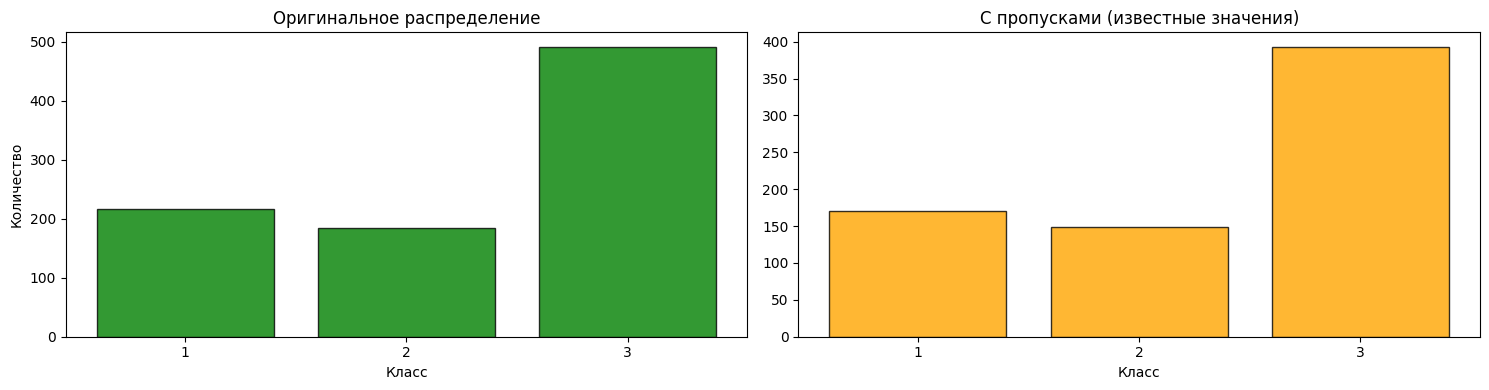

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 1. Оригинальное распределение
axes[0].bar(titanic['Pclass'].value_counts().sort_index().index, 
            titanic['Pclass'].value_counts().sort_index().values,
            color='green', edgecolor='black', alpha=0.8)
axes[0].set_title('Оригинальное распределение')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество')
axes[0].set_xticks([1, 2, 3])

# 2. Распределение с пропусками (только известные значения)
axes[1].bar(titanic_miss['Pclass'].value_counts().sort_index().index, 
            titanic_miss['Pclass'].value_counts().sort_index().values,
            color='orange', edgecolor='black', alpha=0.8)
axes[1].set_title('С пропусками (известные значения)')
axes[1].set_xlabel('Класс')
axes[1].set_xticks([1, 2, 3])

# 3. Сколько пропусков в каждом классе (ПРАВИЛЬНО!)
# Считаем: из всех строк, которые БЫЛИ классом 1, сколько стало NaN?
# Для этого нужно было сохранить оригинальные значения перед созданием пропусков

# Альтернатива: просто показать процент пропусков в целом
total_missing = titanic_miss['Pclass'].isnull().sum()
total_rows = len(titanic_miss)
missing_pct = total_missing / total_rows * 100

plt.tight_layout()
plt.show()

Результат положительный - соотношения в целом остались прежними

#### Разные методы заполнения пропусков

Теперь займёмся разными методами заполнения пропусков. Начнём с Age

In [ ]:
# МЕТОД 1: Заполнение медианой (простой)
titanic_age_median = titanic.copy()
median_age = titanic_age_median['Age'].median()
titanic_age_median['Age'] = titanic_age_median['Age'].fillna(median_age)

print(f"\nМетод 1 (Медиана): заполнено {median_age:.2f} лет")




# МЕТОД 2: Заполнение средним
titanic_age_mean = titanic.copy()
mean_age = titanic_age_mean['Age'].mean()
titanic_age_mean['Age'] = titanic_age_mean['Age'].fillna(mean_age)

print(f"Метод 2 (Среднее): заполнено {mean_age:.2f} лет")





# МЕТОД 3: Заполнение по группам (Sex + Pclass)
# !!! беру набор БЕЗ пропусков в Pclass, иначе не сработает! 
# (на практике можно сперва заполнить классы пассажиров, а потом, при желании, использовать этот метод)
titanic_age_group = titanic.copy()
titanic_age_group['Age'] = titanic_age_group.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

print("Метод 3 (Группы Sex+Pclass): заполнено по медиане групп")





# МЕТОД 4: Предсказание через Random Forest
titanic_age_rf = titanic.copy()

# Подготовка данных
known_age = titanic_age_rf[titanic_age_rf['Age'].notnull()].copy()
unknown_age = titanic_age_rf[titanic_age_rf['Age'].isnull()].copy()

# Кодируем пол
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
le = LabelEncoder()
known_age['Sex_enc'] = le.fit_transform(known_age['Sex'])
unknown_age['Sex_enc'] = le.transform(unknown_age['Sex'])

# Признаки для модели
features = ['Sex_enc', 'Pclass', 'SibSp', 'Parch', 'Fare']
X_known = known_age[features].dropna()
y_known = known_age.loc[X_known.index, 'Age']
X_unknown = unknown_age[features].dropna()

# Обучаем модель
model_age = RandomForestRegressor(n_estimators=100, random_state=42)
model_age.fit(X_known, y_known)

# Предсказываем
predicted_ages = model_age.predict(X_unknown)
titanic_age_rf.loc[X_unknown.index, 'Age'] = predicted_ages

# Оставшиеся пропуски заполняем медианой
titanic_age_rf['Age'] = titanic_age_rf['Age'].fillna(titanic_age_rf['Age'].median())

print(f"Метод 4 (Random Forest): R^2 на известных = {model_age.score(X_known, y_known):.4f}")

# СРАВНЕНИЕ МЕТОДОВ для Age
print("СРАВНЕНИЕ МЕТОДОВ ОБРАБОТКИ Age")

comparison_age = pd.DataFrame({
    'Метод': ['Оригинал', 'Медиана', 'Среднее', 'Группы', 'Random Forest'],
    'Средний возраст': [
        titanic['Age'].mean(),
        titanic_age_median['Age'].mean(),
        titanic_age_mean['Age'].mean(),
        titanic_age_group['Age'].mean(),
        titanic_age_rf['Age'].mean()
    ],
    'Медиана возраста': [
        titanic['Age'].median(),
        titanic_age_median['Age'].median(),
        titanic_age_mean['Age'].median(),
        titanic_age_group['Age'].median(),
        titanic_age_rf['Age'].median()
    ],
    'Стд. отклонение': [
        titanic['Age'].std(),
        titanic_age_median['Age'].std(),
        titanic_age_mean['Age'].std(),
        titanic_age_group['Age'].std(),
        titanic_age_rf['Age'].std()
    ]
})

print(comparison_age.to_string(index=False))

print(f"Пропусков в Age после обработки: {titanic_age_median['Age'].isnull().sum()}")


Метод 1 (Медиана): заполнено 28.00 лет
Метод 2 (Среднее): заполнено 29.70 лет
Метод 3 (Группы Sex+Pclass): заполнено по медиане групп
Метод 4 (Random Forest): R^2 на известных = 0.6828
СРАВНЕНИЕ МЕТОДОВ ОБРАБОТКИ Age
        Метод  Средний возраст  Медиана возраста  Стд. отклонение
     Оригинал        29.699118         28.000000        14.526497
      Медиана        29.361582         28.000000        13.019697
      Среднее        29.699118         29.699118        13.002015
       Группы        29.112424         26.000000        13.304424
Random Forest        29.607346         28.000000        13.684690
Пропусков в Age после обработки: 0


Теперь попробуем разные методы заполнения Pclass

In [ ]:
# МЕТОД 1: Заполнение модой (простой)
titanic_pclass_mode = titanic_miss.copy()
mode_pclass = titanic_pclass_mode['Pclass'].mode()[0]
titanic_pclass_mode['Pclass'] = titanic_pclass_mode['Pclass'].fillna(mode_pclass)

print(f"\nМетод 1 (Мода): заполнено классом {mode_pclass}")




# МЕТОД 2: Заполнение по Fare (логическое)
titanic_pclass_fare = titanic_miss.copy()

def fill_pclass_by_fare(row):
    if pd.isnull(row['Pclass']):
        fare = row['Fare']
        if fare >= 50: # стоимость билета и классность пассажиров чётко коррелировали на Титанике
            # но даже так - можно было бы просто поисслдовать датасет и всё равно посчитать
            # на основе ненулевых значений в столбце
            return 1
        elif fare >= 15:
            return 2
        else:
            return 3
    return row['Pclass']

titanic_pclass_fare['Pclass'] = titanic_pclass_fare.apply(fill_pclass_by_fare, axis=1)
#print("Метод 2 (По Fare): заполнено на основе цены билета")




# МЕТОД 3: Предсказание через Random Forest
titanic_pclass_rf = titanic_miss.copy()

# Подготовка данных
known_pclass = titanic_pclass_rf[titanic_pclass_rf['Pclass'].notnull()].copy()
unknown_pclass = titanic_pclass_rf[titanic_pclass_rf['Pclass'].isnull()].copy()

# Кодируем пол
known_pclass['Sex_enc'] = le.fit_transform(known_pclass['Sex'])
unknown_pclass['Sex_enc'] = le.transform(unknown_pclass['Sex'])

# Признаки для модели
features = ['Sex_enc', 'Age', 'SibSp', 'Parch', 'Fare']
X_known = known_pclass[features].dropna()
y_known = known_pclass.loc[X_known.index, 'Pclass']
X_unknown = unknown_pclass[features].dropna()

# Обучаем модель
from sklearn.ensemble import RandomForestClassifier
model_pclass = RandomForestClassifier(n_estimators=100, random_state=42)
model_pclass.fit(X_known, y_known)

# Предсказываем
predicted_pclass = model_pclass.predict(X_unknown)
titanic_pclass_rf.loc[X_unknown.index, 'Pclass'] = predicted_pclass

# Оставшиеся пропуски заполняем модой
titanic_pclass_rf['Pclass'] = titanic_pclass_rf['Pclass'].fillna(titanic_pclass_rf['Pclass'].mode()[0])

print(f"Метод 3 (Random Forest): точность = {model_pclass.score(X_known, y_known):.4f}")


# СРАВНЕНИЕ МЕТОДОВ для Pclass
print("СРАВНЕНИЕ МЕТОДОВ ОБРАБОТКИ Pclass")

comparison_pclass = pd.DataFrame({
    'Метод': ['Оригинал', 'Мода', 'По Fare', 'Random Forest'],
    'Строк': [
        len(titanic),
        len(titanic_pclass_mode),
        len(titanic_pclass_fare),
        len(titanic_pclass_rf),
    ],
    'Класс 1 (%)': [
        (titanic['Pclass'] == 1).mean()*100,
        (titanic_pclass_mode['Pclass'] == 1).mean()*100,
        (titanic_pclass_fare['Pclass'] == 1).mean()*100,
        (titanic_pclass_rf['Pclass'] == 1).mean()*100
    ],
    'Класс 2 (%)': [
        (titanic['Pclass'] == 2).mean()*100,
        (titanic_pclass_mode['Pclass'] == 2).mean()*100,
        (titanic_pclass_fare['Pclass'] == 2).mean()*100,
        (titanic_pclass_rf['Pclass'] == 2).mean()*100
    ],
    'Класс 3 (%)': [
        (titanic['Pclass'] == 3).mean()*100,
        (titanic_pclass_mode['Pclass'] == 3).mean()*100,
        (titanic_pclass_fare['Pclass'] == 3).mean()*100,
        (titanic_pclass_rf['Pclass'] == 3).mean()*100
    ]
})

print(comparison_pclass.to_string(index=False))


Метод 1 (Мода): заполнено классом 3.0
Метод 3 (Random Forest): точность = 1.0000
СРАВНЕНИЕ МЕТОДОВ ОБРАБОТКИ Pclass
        Метод  Строк  Класс 1 (%)  Класс 2 (%)  Класс 3 (%)
     Оригинал    891    24.242424    20.650954    55.106622
         Мода    891    19.191919    16.722783    64.085297
      По Fare    891    22.783389    22.671156    54.545455
Random Forest    891    23.681257    19.640853    56.677890


Сделаем и визуализацию для наглядности

Графики для Age


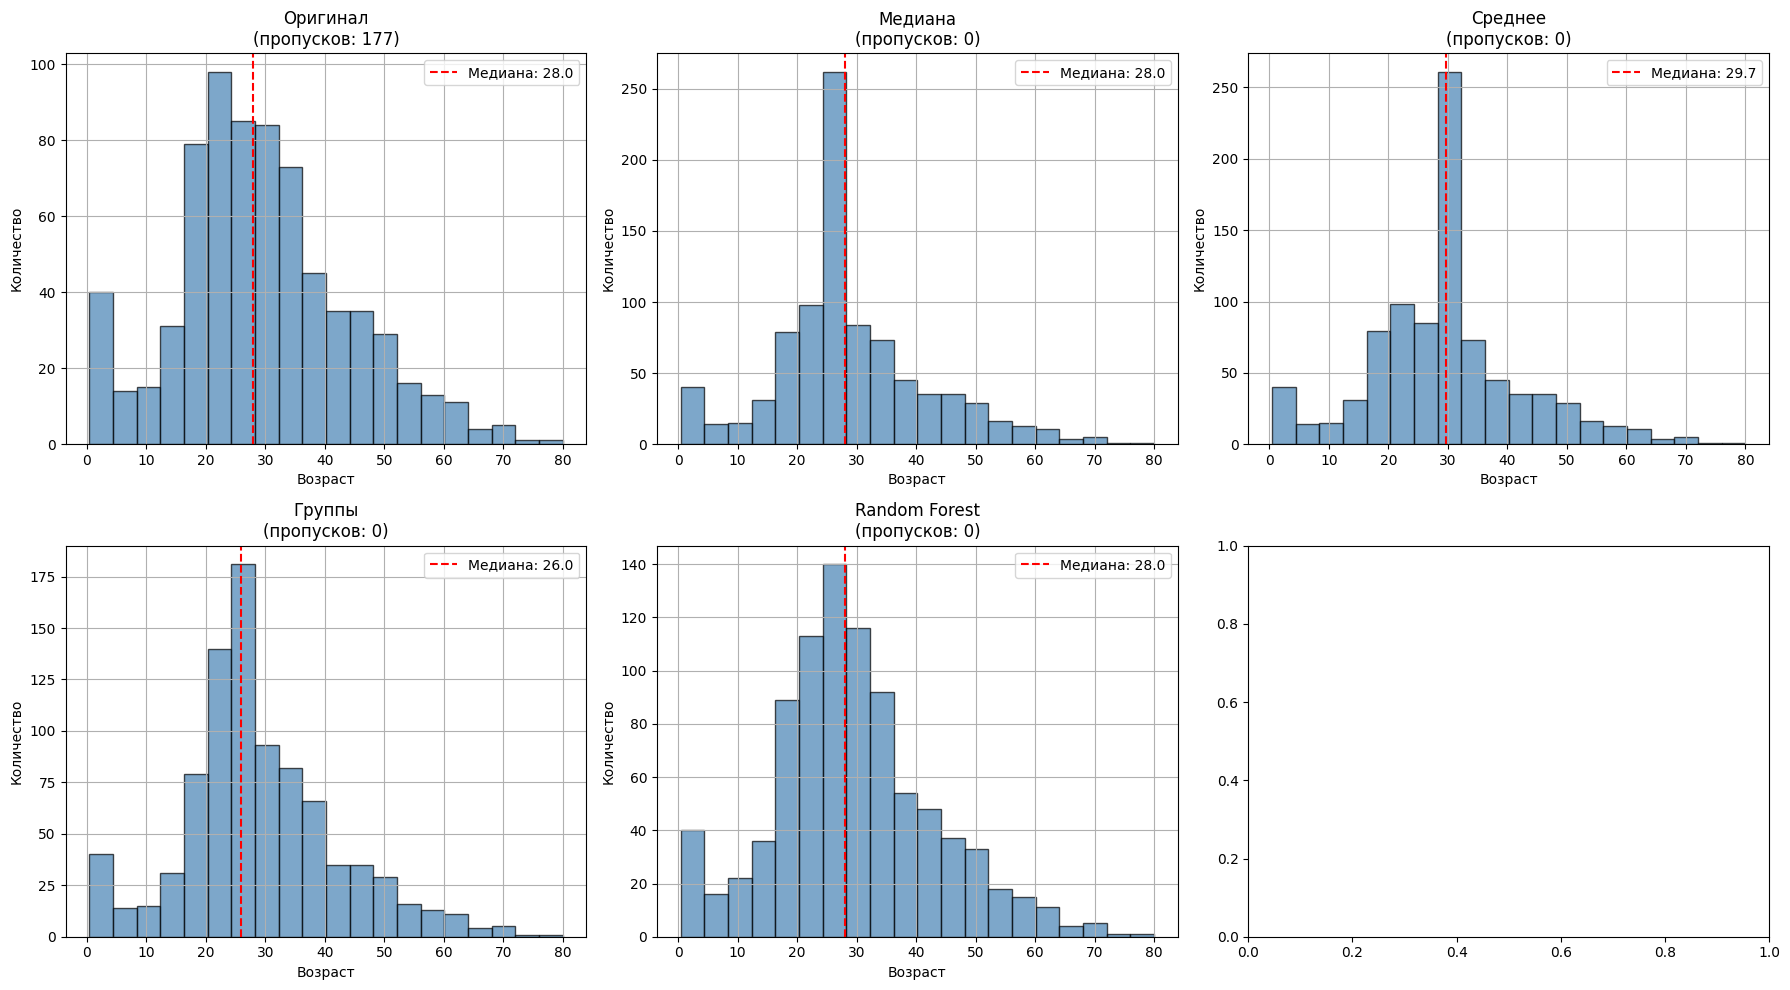

Графики для Pclass


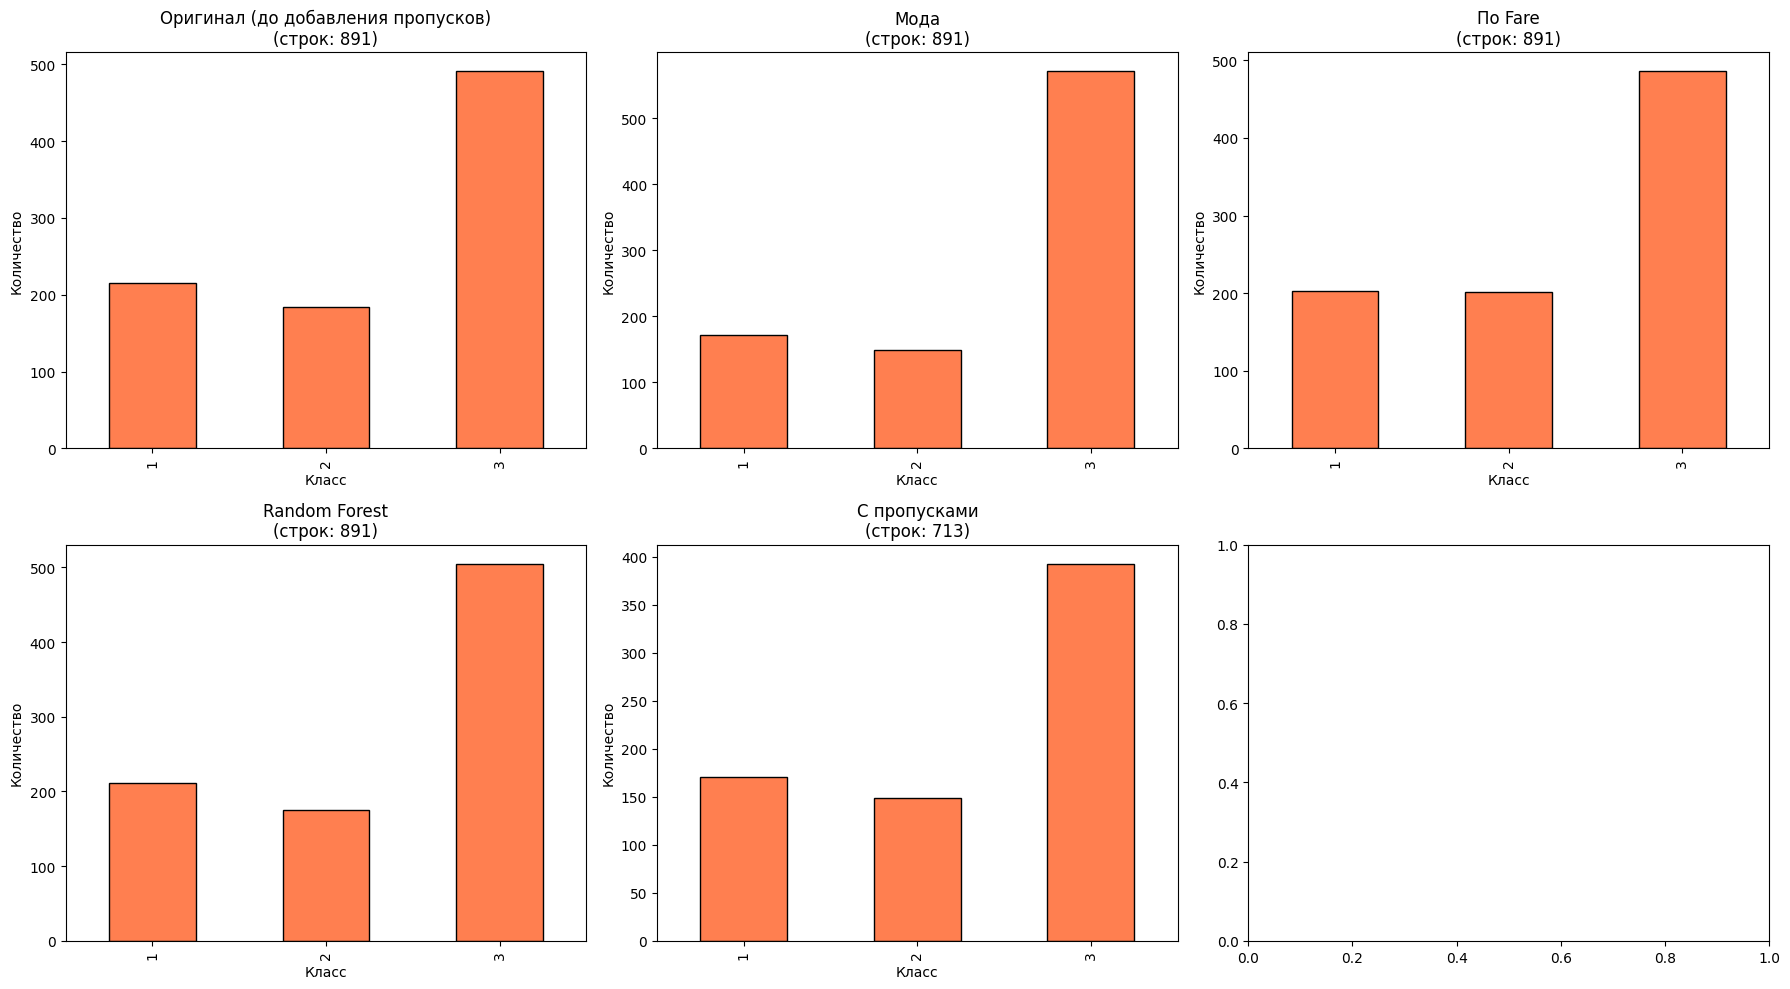

In [13]:
# Графики для Age
print("Графики для Age")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

methods_age = [
    ('Оригинал', titanic_miss['Age']),
    ('Медиана', titanic_age_median['Age']),
    ('Среднее', titanic_age_mean['Age']),
    ('Группы', titanic_age_group['Age']),
    ('Random Forest', titanic_age_rf['Age'])
]

for ax, (name, data) in zip(axes[:5], methods_age):
    data.hist(bins=20, ax=ax, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(data.median(), color='red', linestyle='--', label=f'Медиана: {data.median():.1f}')
    ax.set_title(f'{name}\n(пропусков: {data.isnull().sum()})')
    ax.set_xlabel('Возраст')
    ax.set_ylabel('Количество')
    ax.legend()

plt.tight_layout()
plt.show()

# Графики для Pclass
print("Графики для Pclass")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

methods_pclass = [
    ('Оригинал (до добавления пропусков)', titanic['Pclass']),
    ('Мода', titanic_pclass_mode['Pclass']),
    ('По Fare', titanic_pclass_fare['Pclass']),
    ('Random Forest', titanic_pclass_rf['Pclass']),
    ('С пропусками', titanic_miss['Pclass'].dropna()),
]

for ax, (name, data) in zip(axes[:5], methods_pclass):
    data.value_counts().sort_index().plot(kind='bar', ax=ax, edgecolor='black', color='coral')
    ax.set_title(f'{name}\n(строк: {len(data)})')
    ax.set_xlabel('Класс')
    ax.set_ylabel('Количество')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['1', '2', '3'])

plt.tight_layout()
plt.show()

Лучше всего в плане заполнения пропусков для категориального признака показал себя Random Forest, а вот для числового признака лучше всего показывают себя также Random Forest и заполнение по группам

#### Кодирование категориальных признаков

Теперь займёмся кодированием категориальных признаков. Для этого возьмем набор titanic_age_rf и в нём закодируем ряд признаков:
1) Label Encoding для бинарного признака (пол)
2) One-Hot Encoding для номинального признака (Embarked) (для удобства, просто удали пропуски, ибо не влияют на статистику)
3) Ordinal Encoding для порядкового значения (Pclass)

##### Label Encoding

In [ ]:
# Копируем данные
titanic_encoded = titanic_age_rf.copy() 

# через map
titanic_encoded['Sex_encoded'] = titanic_encoded['Sex'].map({'male': 0, 'female': 1})

print("Кодирование через map")
print(titanic_encoded[['Sex', 'Sex_encoded']].head(10))
print(f"Уникальные значения: {titanic_encoded['Sex_encoded'].unique()}")

# # Через LabelEncoder (sklearn) - слишком брутально для бинарного признака
# from sklearn.preprocessing import LabelEncoder

# le_sex = LabelEncoder()
# titanic_encoded['Sex_le'] = le_sex.fit_transform(titanic_encoded['Sex'])

# print("\nКодирование через LabelEncoder")
# print(f"Классы: {le_sex.classes_}")  # ['female', 'male'] → [0, 1]
# print(titanic_encoded[['Sex', 'Sex_le']].head(10))

Кодирование через map
      Sex  Sex_encoded
0    male            0
1  female            1
2  female            1
3  female            1
4    male            0
5    male            0
6    male            0
7    male            0
8  female            1
9  female            1
Уникальные значения: [0 1]


##### One-Hot Encoding 

In [15]:
# Через pd.get_dummies 
titanic_ohe = titanic_encoded.copy()

# Создаём отдельные столбцы для каждой категории
titanic_ohe = pd.get_dummies(titanic_ohe, columns=['Embarked'], prefix='Embarked')

print("One-Hot Encoding через get_dummies")
print(f"Новые столбцы: {[i for i in titanic_ohe.columns if 'Embarked' in i]}")
print(titanic_ohe[['Embarked_S', 'Embarked_C', 'Embarked_Q']].head(10))

One-Hot Encoding через get_dummies
Новые столбцы: ['Embarked_C', 'Embarked_Q', 'Embarked_S']
   Embarked_S  Embarked_C  Embarked_Q
0        True       False       False
1       False        True       False
2        True       False       False
3        True       False       False
4        True       False       False
5       False       False        True
6        True       False       False
7        True       False       False
8        True       False       False
9       False        True       False


формально, один столбец здесь лишний, ибо легко вычисляем, но пусть будет :)

##### Ordinal Encoding

In [16]:
# Pclass: уже числовой, но проверяем порядок
print("Pclass: проверка порядка")
print(f"Уникальные значения: {sorted(titanic['Pclass'].unique())}")
print(f"Тип данных: {titanic_encoded['Pclass'].dtype}")

# Если бы Pclass был строкой:
# df['Pclass_str'] = df['Pclass'].astype(str) + ' класс'
# Тогда нужно кодировать с указанием порядка:

# Пример: гипотетический столбец Education
# titanic_encoded['Education'] = np.random.choice(
#     ['High School', 'Bachelor', 'Master', 'PhD'], 
#     size=len(titanic_encoded)
# )

# # Ordinal Encoding с явным порядком
# education_order = ['High School', 'Bachelor', 'Master', 'PhD']
# education_mapping = {val: idx for idx, val in enumerate(education_order)}

# titanic_encoded['Education_encoded'] = titanic_encoded['Education'].map(education_mapping)

# print(titanic_encoded[['Education', 'Education_encoded']].head(10))


Pclass: проверка порядка
Уникальные значения: [np.int64(1), np.int64(2), np.int64(3)]
Тип данных: int64


Окей, теперь приступим к масштабированию!

#### Масштабирование

In [19]:
from sklearn.preprocessing import MinMaxScaler

titanic_age_rf_scaled = titanic_age_rf.copy()

titanic_age_rf_scaled = titanic_age_rf_scaled.drop(columns=["PassengerId", "Survived", "Parch"])

num_cols_to_scale = ['Age']  

#scaler = StandardScaler() # стандартное масштабирование 
scaler_min_max = MinMaxScaler(feature_range=(0, 1)) 
titanic_scaled = titanic_ohe.copy()  # берем уже закодированные данные
titanic_scaled[num_cols_to_scale] = scaler_min_max.fit_transform(titanic_ohe[num_cols_to_scale])

#titanic_scaled["Name"] = titanic["Name"]

print("Размер итогового датасета:", titanic_scaled.shape)
print(titanic_scaled.head())

Размер итогового датасета: (891, 12)
   PassengerId  Survived  Pclass     Sex       Age  SibSp  Parch     Fare  \
0            1         0       3    male  0.271174      1      0   7.2500   
1            2         1       1  female  0.472229      1      0  71.2833   
2            3         1       3  female  0.321438      0      0   7.9250   
3            4         1       1  female  0.434531      1      0  53.1000   
4            5         0       3    male  0.434531      0      0   8.0500   

   Sex_encoded  Embarked_C  Embarked_Q  Embarked_S  
0            0       False       False        True  
1            1        True       False       False  
2            1       False       False        True  
3            1       False       False        True  
4            0       False       False        True  


Наконец, добавим недостающие столбцы из исходного датасета и получим готовый результат

In [20]:
# Выбрать только недостающие столбцы из оригинала
missing_cols = [col for col in titanic_origin.columns if col not in titanic_scaled.columns]
titanic_missing = titanic_origin[missing_cols]

final_data = titanic_scaled.copy()

# Объединить с final_data
final_data = pd.concat([final_data, titanic_missing], axis=1)

print("Итоговый размер датасета:", final_data.shape)

final_data.head(10)

Итоговый размер датасета: (891, 16)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Sex_encoded,Embarked_C,Embarked_Q,Embarked_S,Name,Ticket,Cabin,Embarked
0,1,0,3,male,0.271174,1,0,7.2500,0,False,False,True,"Braund, Mr. Owen Harris",A/5 21171,NaN,S
1,2,1,1,female,0.472229,1,0,71.2833,1,True,False,False,"Cumings, Mrs. John Bradley (Florence Briggs Th...",PC 17599,C85,C
2,3,1,3,female,0.321438,0,0,7.9250,1,False,False,True,"Heikkinen, Miss. Laina",STON/O2. 3101282,NaN,S
3,4,1,1,female,0.434531,1,0,53.1000,1,False,False,True,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",113803,C123,S
4,5,0,3,male,0.434531,0,0,8.0500,0,False,False,True,"Allen, Mr. William Henry",373450,NaN,S
5,6,0,3,male,0.295694,0,0,8.4583,0,False,True,False,"Moran, Mr. James",330877,NaN,Q
6,7,0,1,male,0.673285,0,0,51.8625,0,False,False,True,"McCarthy, Mr. Timothy J",17463,E46,S
7,8,0,3,male,0.019854,3,1,21.0750,0,False,False,True,"Palsson, Master. Gosta Leonard",349909,NaN,S
8,9,1,3,female,0.334004,0,2,11.1333,1,False,False,True,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",347742,NaN,S
9,10,1,2,female,0.170646,1,0,30.0708,1,True,False,False,"Nasser, Mrs. Nicholas (Adele Achem)",237736,NaN,C
